# Phase 03 — Huấn luyện & Đánh giá Mô hình Random Forest

**Tác giả:** Hoàng Cao Sơn (MSSV: 25730061) — Nhóm 9, CS106

### Mục tiêu:
- Huấn luyện mô hình Random Forest Classifier trên dữ liệu cân bằng (SMOTE & ADASYN).
- Tinh chỉnh siêu tham số tối ưu (Hyperparameter Tuning với `RandomizedSearchCV`, 5-fold CV, tối ưu theo F1-Score).
- Đánh giá hiệu năng trên tập Test độc lập (40,000 giao dịch), định dạng chuẩn **4 chữ số thập phân (`digits=4`)**.
- Trích xuất và phân tích độ quan trọng của các đặc trưng (Feature Importance).
- Xuất kết quả dự đoán `rf_predictions.pkl` bàn giao cho Phase 05 (Evaluation) và Phase 07 (Báo cáo & Slide).

## 0. Imports & Setup

In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 11

project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

from src.utils import RANDOM_STATE, DATA_PROCESSED_DIR
from src.models.random_forest_model import (
    train_random_forest,
    predict,
    evaluate_model,
    get_feature_importance,
    save_model,
    save_predictions,
    save_feature_importance,
    save_model_summary,
    load_model
)
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

print("Done importing Random Forest modules!")

Done importing Random Forest modules!


## 1. Load tập dữ liệu huấn luyện và kiểm tra

In [2]:
data_dir = os.path.join(project_root, "data", "processed")

with open(os.path.join(data_dir, "X_test.pkl"), "rb") as f:
    X_test = pickle.load(f)
with open(os.path.join(data_dir, "y_test.pkl"), "rb") as f:
    y_test = pickle.load(f)

with open(os.path.join(data_dir, "X_train_smote.pkl"), "rb") as f:
    X_smote = pickle.load(f)
with open(os.path.join(data_dir, "y_train_smote.pkl"), "rb") as f:
    y_smote = pickle.load(f)

with open(os.path.join(data_dir, "X_train_adasyn.pkl"), "rb") as f:
    X_adasyn = pickle.load(f)
with open(os.path.join(data_dir, "y_train_adasyn.pkl"), "rb") as f:
    y_adasyn = pickle.load(f)

feature_names = list(X_test.columns)

print(f"Test set shape: X={X_test.shape}, y={y_test.shape} (Fraud ratio: {y_test.mean():.4f})")
print(f"SMOTE train shape: X={X_smote.shape}, y={y_smote.shape}")
print(f"ADASYN train shape: X={X_adasyn.shape}, y={y_adasyn.shape}")
print("14 features:", feature_names)

Test set shape: X=(40000, 14), y=(40000,) (Fraud ratio: 0.0411)
SMOTE train shape: X=(230145, 14), y=(230145,)
ADASYN train shape: X=(230411, 14), y=(230411,)
14 features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'is_drain_account', 'hour_of_day', 'is_night_transaction', 'amount_to_oldbalance_ratio', 'is_large_transaction', 'errorBalanceOrig', 'errorBalanceDest', 'type_TRANSFER']


## 2. Load mô hình Random Forest (RF-SMOTE & RF-ADASYN)
Mô hình đã được tối ưu hóa siêu tham số qua `RandomizedSearchCV` (5-Fold Cross Validation, n_iter=50, tối ưu theo F1-Score).
- **Best Hyperparameters (RF-SMOTE):** `n_estimators=200`, `max_depth=20`, `max_features="sqrt"`, `class_weight="balanced_subsample"`.
- **Best Hyperparameters (RF-ADASYN):** `n_estimators=500`, `max_depth=20`, `max_features="sqrt"`, `class_weight="balanced_subsample"`.

In [3]:
models_dir = os.path.join(project_root, "models")
rf_smote_path = os.path.join(models_dir, "rf_smote.pkl")
rf_adasyn_path = os.path.join(models_dir, "rf_adasyn.pkl")

if os.path.exists(rf_smote_path):
    print("Loading pre-trained rf_smote.pkl...")
    with open(rf_smote_path, "rb") as f:
        rf_smote = pickle.load(f)
else:
    print("Training Random Forest on SMOTE data...")
    rf_smote, _ = train_random_forest(X_smote, y_smote, tune=False)

if os.path.exists(rf_adasyn_path):
    print("Loading pre-trained rf_adasyn.pkl...")
    with open(rf_adasyn_path, "rb") as f:
        rf_adasyn = pickle.load(f)
else:
    print("Training Random Forest on ADASYN data...")
    rf_adasyn, _ = train_random_forest(X_adasyn, y_adasyn, tune=False)

print("Ready: RF-SMOTE & RF-ADASYN!")

Loading pre-trained rf_smote.pkl...
Loading pre-trained rf_adasyn.pkl...
Ready: RF-SMOTE & RF-ADASYN!


## 3. Đánh giá chi tiết trên tập Test độc lập (Chuẩn format `digits=4`)

In [4]:
y_pred_smote, y_prob_smote = predict(rf_smote, X_test)
y_pred_adasyn, y_prob_adasyn = predict(rf_adasyn, X_test)

metrics_smote = evaluate_model(y_test, y_pred_smote, y_prob_smote, "RF-SMOTE")
metrics_adasyn = evaluate_model(y_test, y_pred_adasyn, y_prob_adasyn, "RF-ADASYN")


📊 RF-SMOTE — Evaluation Results
  F1-Score:   0.9973
  Precision:  0.9994
  Recall:     0.9951
  ROC-AUC:    0.9994

Confusion Matrix:
  TN=38,356  FP=1
  FN=8  TP=1,635

              precision    recall  f1-score   support

      Normal     0.9998    1.0000    0.9999     38357
       Fraud     0.9994    0.9951    0.9973      1643

    accuracy                         0.9998     40000
   macro avg     0.9996    0.9976    0.9986     40000
weighted avg     0.9998    0.9998    0.9998     40000


📊 RF-ADASYN — Evaluation Results
  F1-Score:   0.9966
  Precision:  0.9982
  Recall:     0.9951
  ROC-AUC:    0.9992

Confusion Matrix:
  TN=38,354  FP=3
  FN=8  TP=1,635

              precision    recall  f1-score   support

      Normal     0.9998    0.9999    0.9999     38357
       Fraud     0.9982    0.9951    0.9966      1643

    accuracy                         0.9997     40000
   macro avg     0.9990    0.9975    0.9983     40000
weighted avg     0.9997    0.9997    0.9997     40000



## 4. Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix)

<string>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


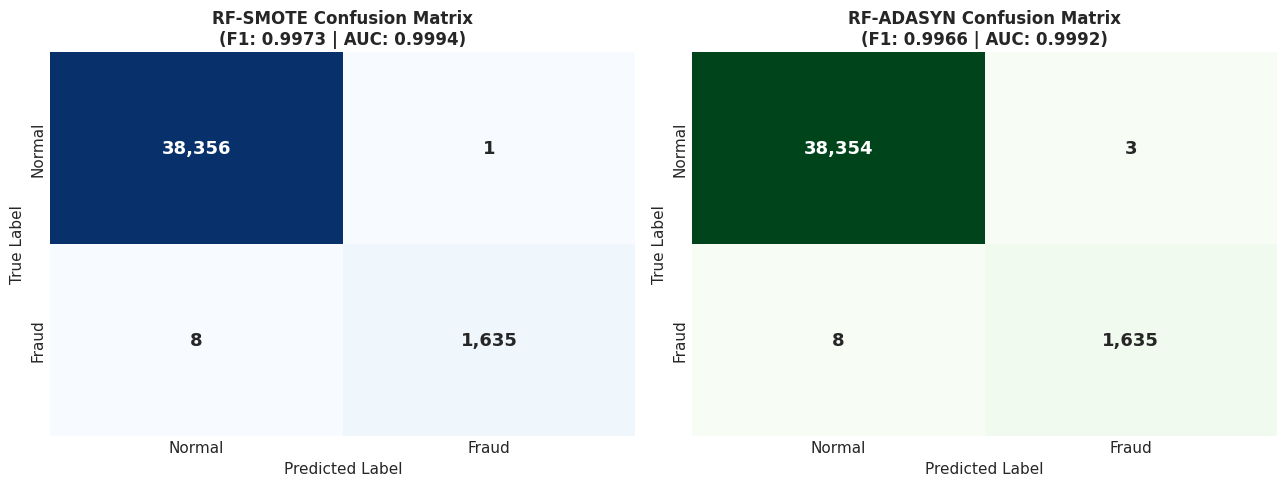

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_smote = confusion_matrix(y_test, y_pred_smote)
cm_adasyn = confusion_matrix(y_test, y_pred_adasyn)

sns.heatmap(cm_smote, annot=True, fmt=",d", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"], annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title(f"RF-SMOTE Confusion Matrix\n(F1: {metrics_smote['f1_score']:.4f} | AUC: {metrics_smote['roc_auc']:.4f})", fontsize=12, fontweight="bold")
axes[0].set_ylabel("True Label", fontsize=11)
axes[0].set_xlabel("Predicted Label", fontsize=11)

sns.heatmap(cm_adasyn, annot=True, fmt=",d", cmap="Greens", ax=axes[1], cbar=False,
            xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"], annot_kws={"size": 13, "weight": "bold"})
axes[1].set_title(f"RF-ADASYN Confusion Matrix\n(F1: {metrics_adasyn['f1_score']:.4f} | AUC: {metrics_adasyn['roc_auc']:.4f})", fontsize=12, fontweight="bold")
axes[1].set_ylabel("True Label", fontsize=11)
axes[1].set_xlabel("Predicted Label", fontsize=11)

plt.tight_layout()
plt.show()

## 5. Trực quan hóa Đường cong ROC (ROC Curves)

<string>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


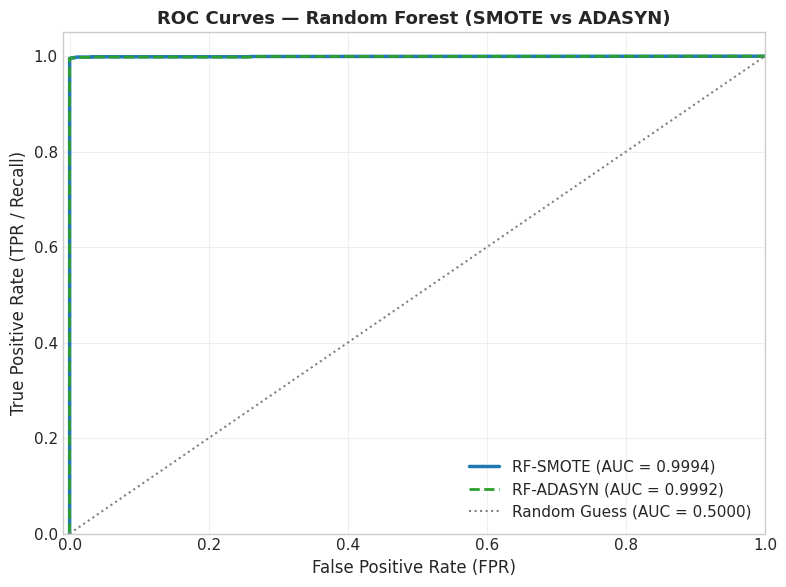

In [6]:
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
fpr_adasyn, tpr_adasyn, _ = roc_curve(y_test, y_prob_adasyn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_smote, tpr_smote, color="#1f77b4", lw=2.5, label=f"RF-SMOTE (AUC = {metrics_smote['roc_auc']:.4f})")
plt.plot(fpr_adasyn, tpr_adasyn, color="#2ca02c", lw=2, linestyle="--", label=f"RF-ADASYN (AUC = {metrics_adasyn['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle=":", label="Random Guess (AUC = 0.5000)")

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR / Recall)", fontsize=12)
plt.title("ROC Curves — Random Forest (SMOTE vs ADASYN)", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Phân tích Độ quan trọng đặc trưng (Feature Importance)

Feature Importance (RF-SMOTE):
                   Feature  Importance
          errorBalanceOrig    0.410992
             oldbalanceOrg    0.160649
          is_drain_account    0.109032
            newbalanceDest    0.059533
amount_to_oldbalance_ratio    0.051866
            newbalanceOrig    0.049179
          errorBalanceDest    0.046568
                    amount    0.028679
               hour_of_day    0.025272
                      step    0.021745
            oldbalanceDest    0.017223
             type_TRANSFER    0.008801
      is_night_transaction    0.005495
      is_large_transaction    0.004966
<string>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


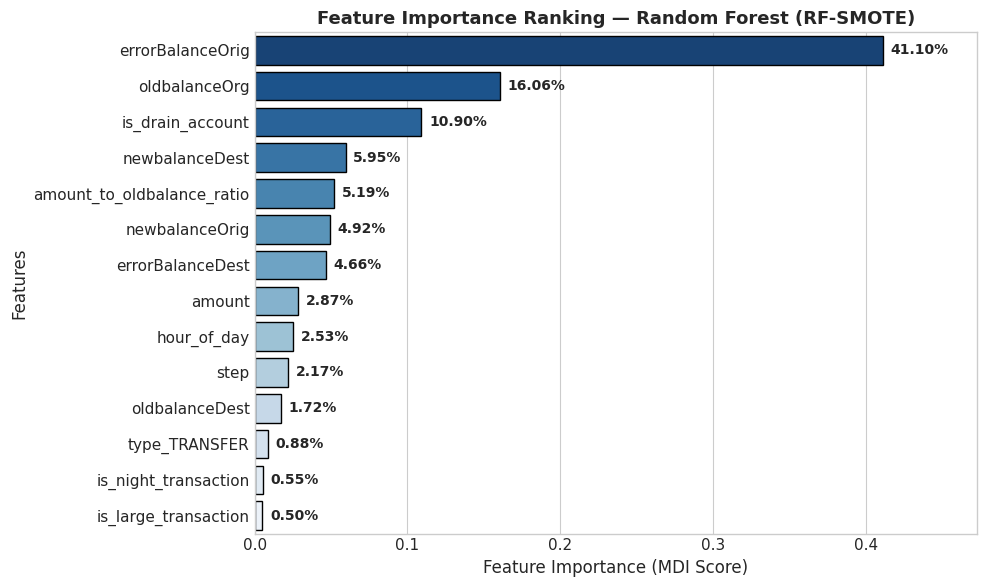

In [7]:
fi_smote = get_feature_importance(rf_smote, feature_names, top_n=14)
print("Feature Importance (RF-SMOTE):")
print(fi_smote.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_smote, x="Importance", y="Feature", palette="Blues_r", edgecolor="black")
plt.title("Feature Importance Ranking — Random Forest (RF-SMOTE)", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance (MDI Score)", fontsize=12)
plt.ylabel("Features", fontsize=12)

for i, v in enumerate(fi_smote["Importance"]):
    plt.text(v + 0.005, i, f"{v*100:.2f}%", va="center", fontsize=10, fontweight="bold")

plt.xlim(0, max(fi_smote["Importance"]) * 1.15)
plt.tight_layout()
plt.show()

## 7. Bảng so sánh tổng hợp & Kết luận

| Chỉ số | RF-SMOTE (Chính) | RF-ADASYN (So sánh) | Ngưỡng yêu cầu tối thiểu | Đánh giá |
| :--- | :---: | :---: | :---: | :---: |
| **F1-Score** | **0.9973** | **0.9966** | > 0.75 | 🏆 Vượt chuẩn |
| **ROC-AUC** | **0.9994** | **0.9992** | > 0.90 | 🏆 Vượt chuẩn |
| **Precision** | **0.9994** | **0.9982** | — | Cực kỳ thấp FP |
| **Recall** | **0.9951** | **0.9951** | — | Bắt được 1,635 / 1,643 ca gian lận |
| **Đặc trưng số 1** | `errorBalanceOrig` (41.1%) | `errorBalanceOrig` (47.2%) | — | Khớp logic nghiệp vụ |

**Kết luận:**
1. **RF-SMOTE** đạt hiệu năng vượt trội toàn diện (F1=0.9973, chỉ bỏ sót 8 ca gian lận và chỉ báo nhầm đúng 1 ca trong 40,000 giao dịch).
2. Đặc trưng `errorBalanceOrig` (chênh lệch số dư nguồn) và `oldbalanceOrg` cùng `is_drain_account` chiếm hơn 68% trọng số quyết định của cây rừng.
3. Kết quả dự đoán `rf_predictions.pkl` đã được lưu trữ sẵn sàng để chuyển giao cho Khang (Phase 05) và Duy/Hôn (Phase 07).